In [2]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
# sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

from solps_funcs import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# I/O

In [3]:
case = SOLPScase('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps')

raw_balance = nc.Dataset('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps/balance.nc')



In [5]:
hermes_case = Load.case_1D('/Users/lloyd/Documents/hermes_dir/simulations_dir/2025-12_intial_solps_baseline/no_geom/sol_ring_0', use_squash=True).ds.isel(t = -1)

for i in hermes_case.data_vars.keys():
    print(i)

print(hermes_case['Te'].units)

- Looking for squash file
- Squash file found. squash date 12/10/2025, 15:13:29, dmp file date 12/10/2025, 15:11:17
Replacing guard cells
Bxy
Ed+_iz
Ed+_rec
Ed_target_recycle
Edd+_cx
Fd+_iz
Fd+_rec
Fdd+_cx
G1
G2
G3
J
Kdd+_cx
NVd
NVd+
Nd
Nd+
Ne
Pd
Pd+
Pd+_src
Pd_src
Pe
Pe_src
Rd+_ex
Rd+_rec
SNVd
SNVd+
SNd
SNd+
SPd
SPd+
SPe
Sd+_feedback
Sd+_iz
Sd+_rec
Sd+_src
Sd_src
Sd_target_recycle
Td
Td+
Te
Vd
Vd+
Ve
ddt(NVd)
ddt(NVd+)
ddt(Nd)
ddt(Nd+)
ddt(Pd)
ddt(Pd+)
ddt(Pe)
density_feedback_src_i_d+
density_feedback_src_mult_d+
density_feedback_src_p_d+
density_feedback_src_shape_d+
efd+_cond_ylow
efd+_kin_ylow
efd+_tot_ylow
efd_cond_ylow
efd_kin_ylow
efd_tot_ylow
efe_cond_ylow
efe_kin_ylow
efe_tot_ylow
g11
g12
g13
g22
g23
g33
g_11
g_12
g_13
g_22
g_23
g_33
iteration
kappa_par_d
kappa_par_d+
kappa_par_e
pfd+_tot_ylow
pfd_tot_ylow
ncalls
ncalls_e
ncalls_i
wall_time
wtime
wtime_comms
wtime_invert
wtime_io
wtime_per_rhs
wtime_per_rhs_e
wtime_per_rhs_i
wtime_rhs
t_array
da
dv
eV


In [ ]:
for i in raw_balance.variables.keys():
    print(i)


crx
cry
bb
hx
hy
hz
vol
gs
qz
am
mp
ev
leftix
leftiy
rightix
rightiy
topix
topiy
bottomix
bottomiy
jxi
jxa
jsep
species
b2mndr_eirene
b2mndr_hz
za
fna_pinch
fna_pll
fna_drift
fna_drift_50
fna_ch
fna_nanom
fna_panom
fna_pschused
fna_vsprcur
fna_tot
b2stbr_phys_sna_bal
b2stbr_bas_sna_bal
b2stbr_first_flight_sna_bal
b2stbc_sna_bal
b2stbm_sna_bal
ext_sna_bal
b2stel_sna_ion_bal
b2stel_sna_rec_bal
b2stcx_sna_bal
b2srsm_sna_bal
b2srdt_sna_bal
b2srst_sna_bal
tot_sna_bal
resco
fmo_flua
fmo_cvsa
fmo_hybr
fmo_b2nxfv
fmo_tot
b2stbr_phys_smo_bal
b2stbr_bas_smo_bal
b2stbc_smo_bal
b2stbm_smo_bal
ext_smo_bal
b2stel_smq_ion_bal
b2stel_smq_rec_bal
b2stcx_smq_bal
b2srsm_smo_bal
b2srdt_smo_bal
b2srst_smo_bal
b2sifr_smoch_bal
b2sifr_smotf_ehxp_bal
b2sifr_smotf_cthe_bal
b2sifr_smotf_cthi_bal
b2sifr_smofrea_bal
b2sifr_smofria_bal
b2sifr_smotfea_bal
b2sifr_smotfia_bal
b2siav_smovh_bal
b2siav_smovv_bal
b2siav_smovi_bal
b2sicf_smo_bal
b2sian_smo_bal
b2nxdv_smo_bal
b2sigp_smogp_bal
b2sigp_smogpi_bal
b2sigp_smogp

# 2D grid

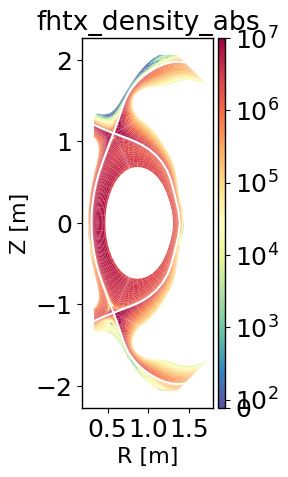

In [ ]:
# %matplotlib widget
fig, ax = plt.subplots()
ax.grid(False)  # Disable grid on this subplot
# label = ['Hermes', 'SOLPS']
vmax = 1e7
vmin = 0
case.plot_2d(param = 'fhtx_density_abs', ax = ax, grid_only = False, vmax = vmax, vmin = vmin, logscale = True)#, linewidth = 0.5)


# Determining parallel cell area

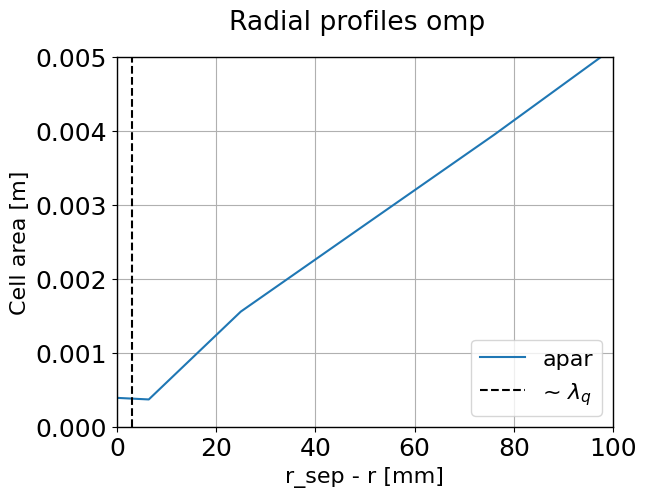

In [ ]:
fline = case.get_1d_radial_data(
    ["Te", "ne", 'Nn', "Pe", 'fhex_total', 'fhix_total', 'fhey_total', 'fhtx', 'gs_par', 'gs_perp', 'hpar', 'vol',
    'hx','Btot', 'Bpol'], 
    region='omp',
    keep_geometry=True,
    poloidal_offset=15
)




# apar_fixed = (fline['vol'] / fline['hpar']) * (fline["Btot"] / fline["Bpol"])
fig,ax = plt.subplots()
# ax.plot(fline['dist']*1e3,fline['gs_perp'], label='gs_perp')
# ax.plot(fline['dist']*1e3,fline["Btot"] / fline["Bpol"], label='Btot/Bpol')
ax.plot(fline['dist']*1e3, fline['apar'], label='apar')
# ax.plot(fline['dist']*1e3, fline['hpar'], label='hpar')
# ax.plot(fline['dist']*1e3, apar_fixed, label='apar_fixed')
ax.axvline(x=3, color='black', linestyle='--', label = r'~ $\lambda_q$')
ax.set_xbound(0, 100)
ax.set_ybound(0, 0.005)
ax.set_ylabel(r"Cell area [m]")
ax.set_xlabel(r"r_sep - r [mm]")
ax.legend()
fig.suptitle('Radial profiles omp')
plt.show()



(67,)
Total parallel heat flux density at xpoint(bpol_min): 3.81e+01 MW/m² 

e/i ratio: 5.58 

Total electron parallel heat flux density: 3.23e+01 MW/m² 

Total ion heat parallel flux density: 5.79e+00 MW/m² 

Ne at Bpol min: 1.05e+00 $10^19$ m$^-3$ \n
Connection length: 27.52 m 

X-point location: 12.59 m 



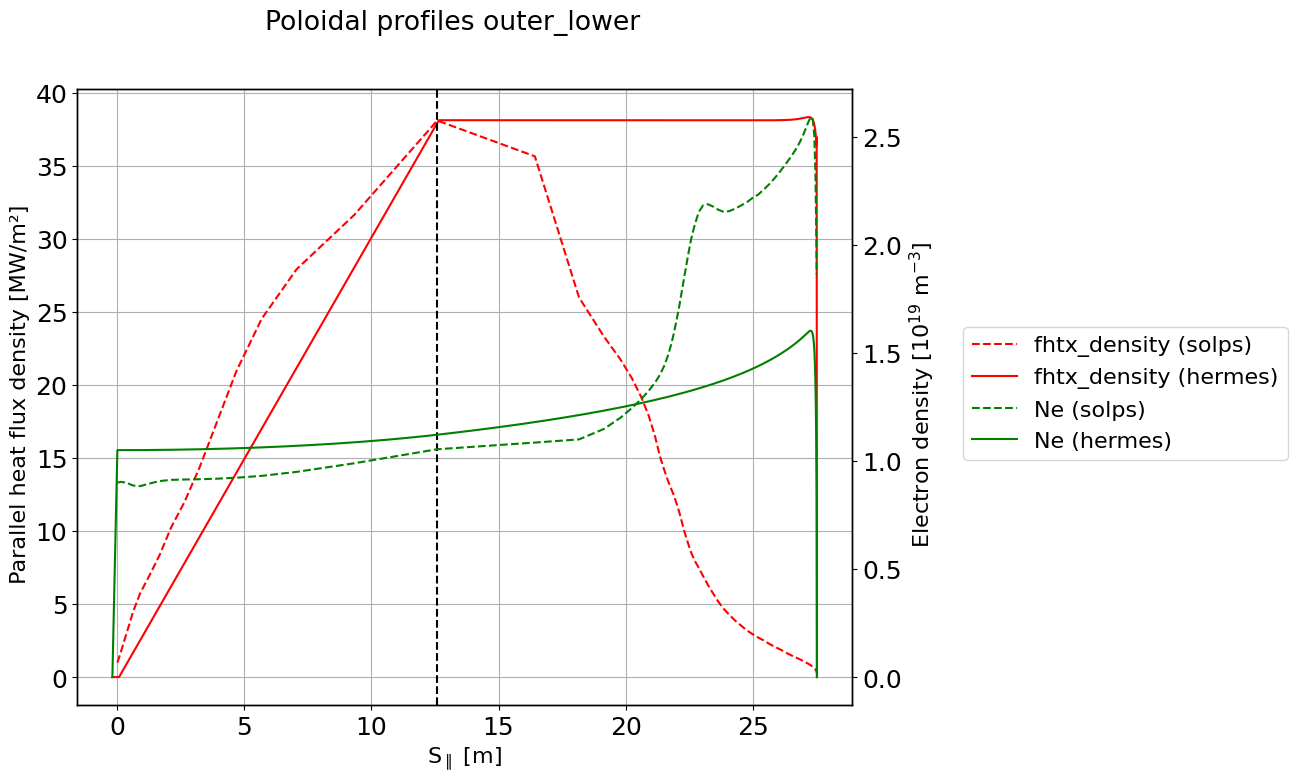

In [ ]:
fline = case.get_1d_poloidal_data(
    params=["gs_par", "gs_perp", 'Bpol', 'fhtx_density', 'Ne', 'fhex_total', 'fhix_total'],   
    region='outer_lower',
    sepadd=0,

)



print(np.shape(fline['Spar']))

# Get index of Bpol minimum (usually X-point)
idx_bpol_min = np.argmin(fline["Bpol"])

fhtx_total = fline["fhtx_density"][idx_bpol_min]    # W/m^2
e_over_i = fline["fhex_total"][idx_bpol_min] / fline["fhix_total"][idx_bpol_min]

print('Total parallel heat flux density at xpoint(bpol_min):', f'{fhtx_total * 1e-6:.2e} MW/m² \n')
print('e/i ratio:', f'{e_over_i:.2f} \n' )

# Calculate required electron and ion heat fluxes given total and e/i ratio
# Let f_e = electron heat flux, f_i = ion heat flux
# fhtx_total = f_e + f_i
# e/i ratio = f_e / f_i
# => f_e = (e_over_i / (1 + e_over_i)) * fhtx_total
# => f_i = (1 / (1 + e_over_i)) * fhtx_total

f_e = (e_over_i / (1 + e_over_i)) * fhtx_total
f_i = (1 / (1 + e_over_i)) * fhtx_total

print(f"Total electron parallel heat flux density: {f_e * 1e-6:.2e} MW/m² \n")
print(f"Total ion heat parallel flux density: {f_i * 1e-6:.2e} MW/m² \n")

print('Ne at Bpol min:', fr'{fline["Ne"][(np.argmin(fline["Bpol"]))] * 1e-19:.2e} $10^{19}$ m$^{-3}$ \n')

print('Connection length:', f'{fline["Spar"].values[-1]:.2f} m \n')
print('X-point location:', f'{fline["Spar"][np.argmin(fline["Bpol"])]:.2f} m \n')

fig,ax = plt.subplots(figsize=(10,8))

ax2 = ax.twinx()
ax.plot(fline['Spar'],fline['fhtx_density'] * 1e-6, label='fhtx_density (solps)', color = 'red', linestyle = '--')
ax.plot(hermes_case['pos'],(hermes_case['efd+_tot_ylow']+hermes_case['efe_tot_ylow'])/hermes_case['da'] * 1e-6, label='fhtx_density (hermes)', color = 'red')
ax2.plot(fline['Spar'],fline['Ne'] * 1e-19, label='Ne (solps)', color = 'green', linestyle = '--')
ax2.plot(hermes_case['pos'],hermes_case['Ne'] * 1e-19, label='Ne (hermes)', color = 'green')
ax.axvline(fline['Spar'][np.argmin(fline['Bpol'])], color = 'black', linestyle = '--')
ax2.grid(False)
ax.set_xlabel(r"S$_\parallel$ [m]")
ax.set_ylabel(r" Parallel heat flux density [MW/m²]")
ax2.set_ylabel(r" Electron density [$10^{19}$ m$^{-3}$]")

fig.suptitle('Poloidal profiles outer_lower')
fig.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Radial profiles for parallel heat flux

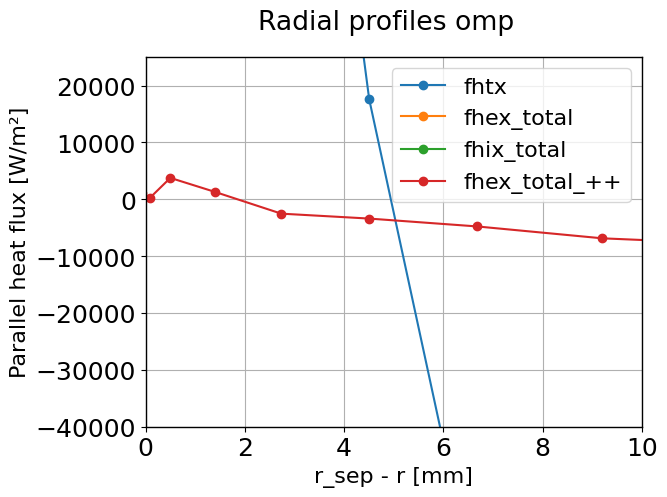

In [ ]:
fline = case.get_1d_radial_data(
    params=["fhtx", "fhex_total", "fhix_total", "fhey_total", 'fhtx', 'fhty', 'R', 'Z', 'gs_par', 'gs_perp'],
    region='omp',
    keep_geometry=True,
    poloidal_offset=1
)




fig,ax = plt.subplots()
ax.plot(fline['dist']*1e3,fline['fhtx']/fline['gs_par'], label='fhtx', marker='o')
ax.plot(fline['dist']*1e3,fline['fhex_total']/fline['gs_par'], label='fhex_total', marker='o')
ax.plot(fline['dist']*1e3,fline['fhix_total']/fline['gs_par'], label='fhix_total', marker='o')
ax.plot(fline['dist']*1e3,fline['fhex_total'] + fline['fhix_total'], label='fhex_total_++', marker='o')
# ax.plot(fline['dist']*1e3,fline['fhey_total'], label='fhey_total')
# ax.plot(fline['dist']*1e3,fline['fhtx'], label='fhtx')
# ax.plot(fline['dist']*1e3,fline['fhty'], label='fhty')


# case.plot_2d('Te', ax = ax, grid_only = False)

# ax.plot(fline['R'], fline['Z'], 'o', label='R,Z')

ax.set_xbound(0, 10)
ax.set_ybound(-4e4, 2.5e4)
ax.set_xlabel(r"r_sep - r [mm]")
ax.set_ylabel(r"Parallel heat flux [W/m²]")
ax.legend()
fig.suptitle('Radial profiles omp')
plt.show()





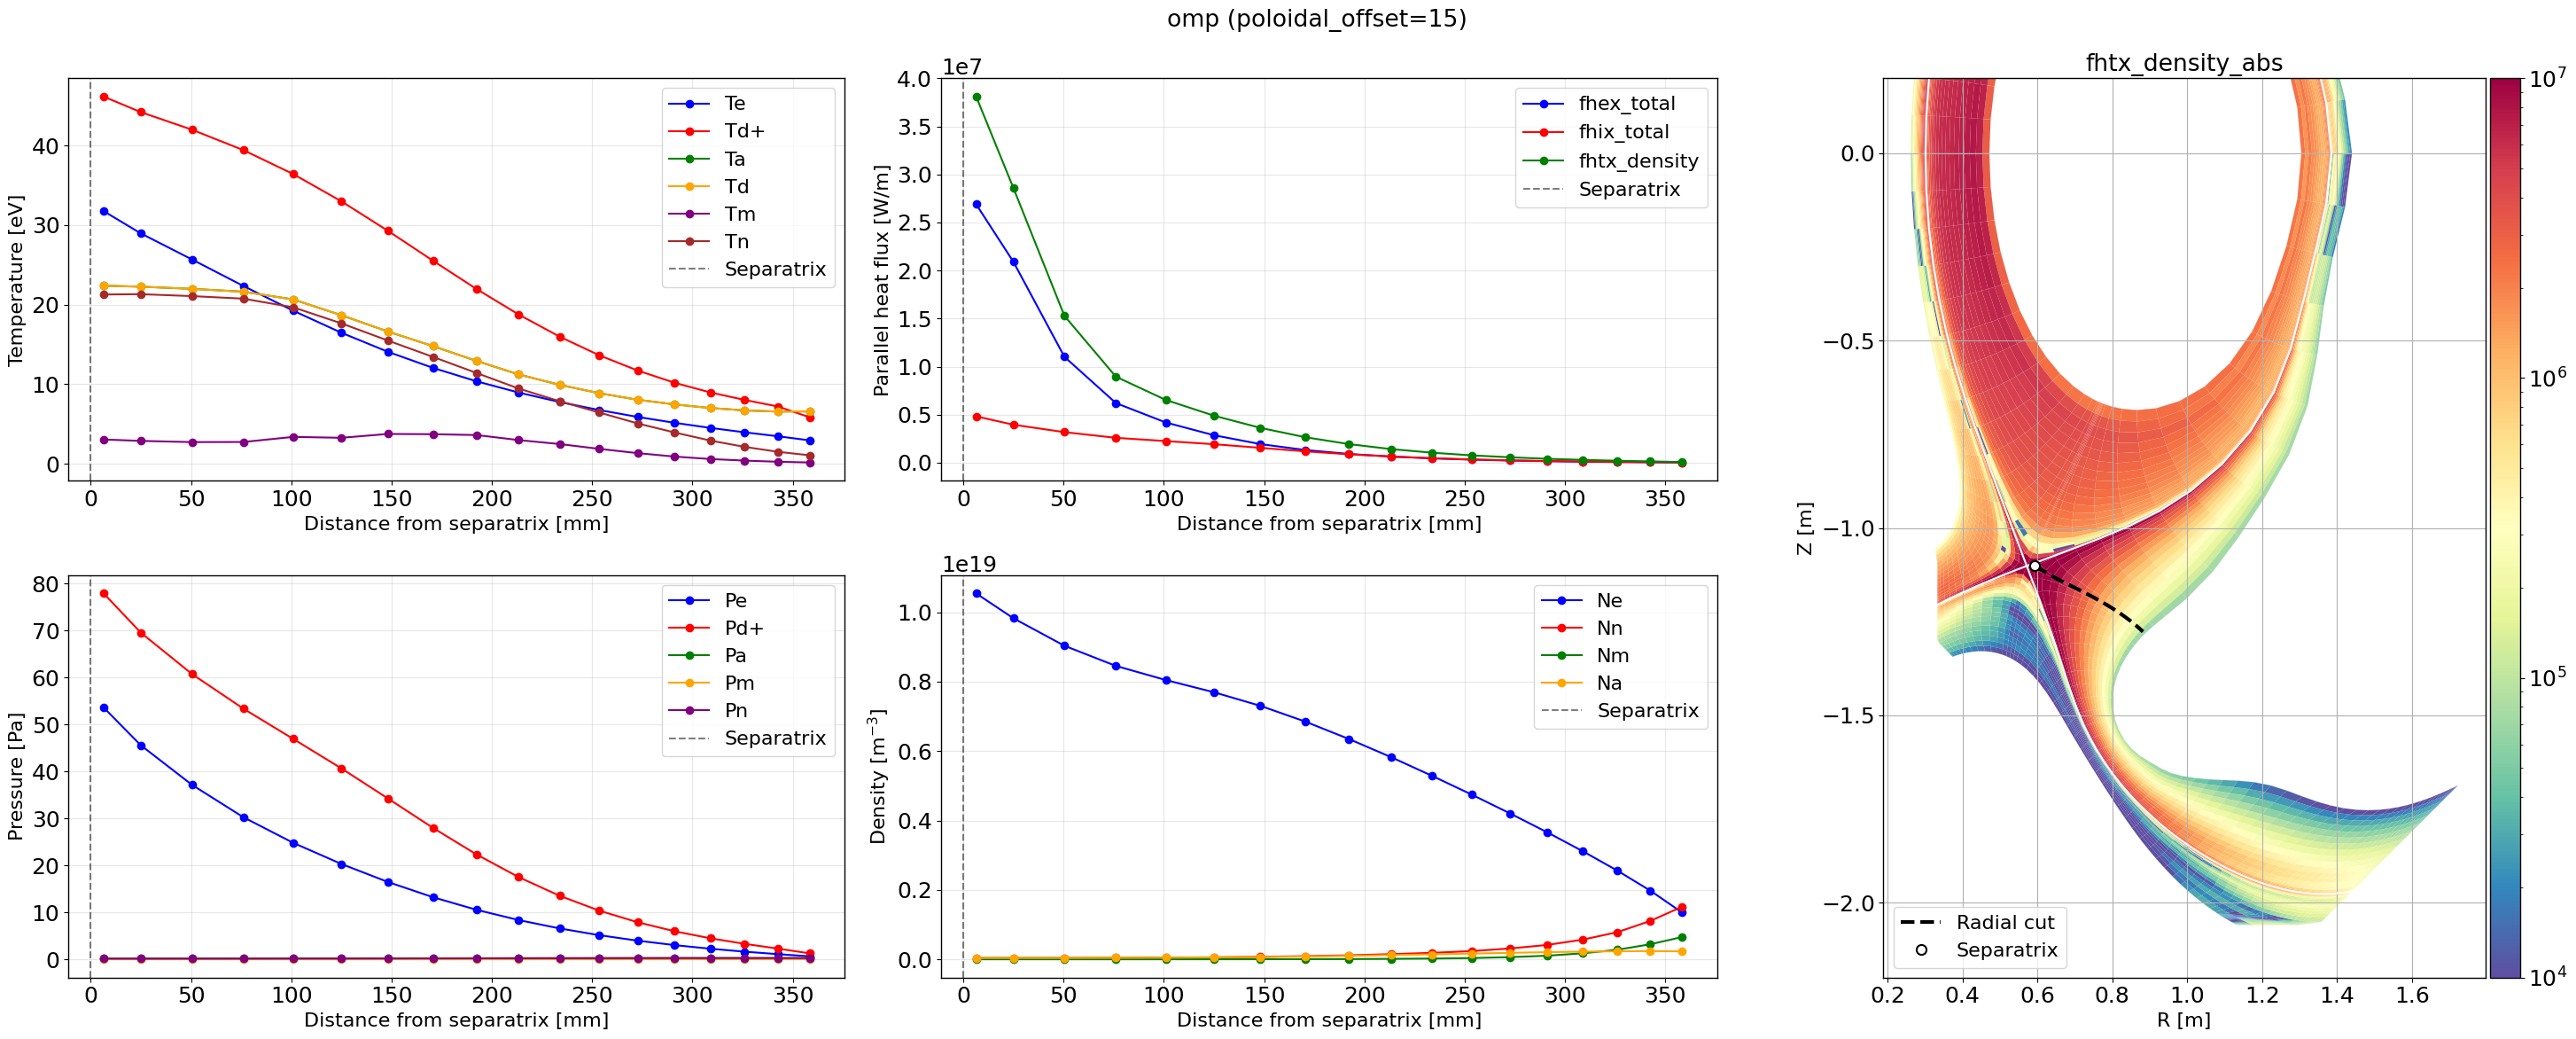

In [ ]:
plot_radial_profiles(case, region='omp', poloidal_offset=15, zoom = False, param_2d = 'fhtx_density_abs', grid_only = False, cfr_only = True, vmin = 1e4, vmax = 1e7)


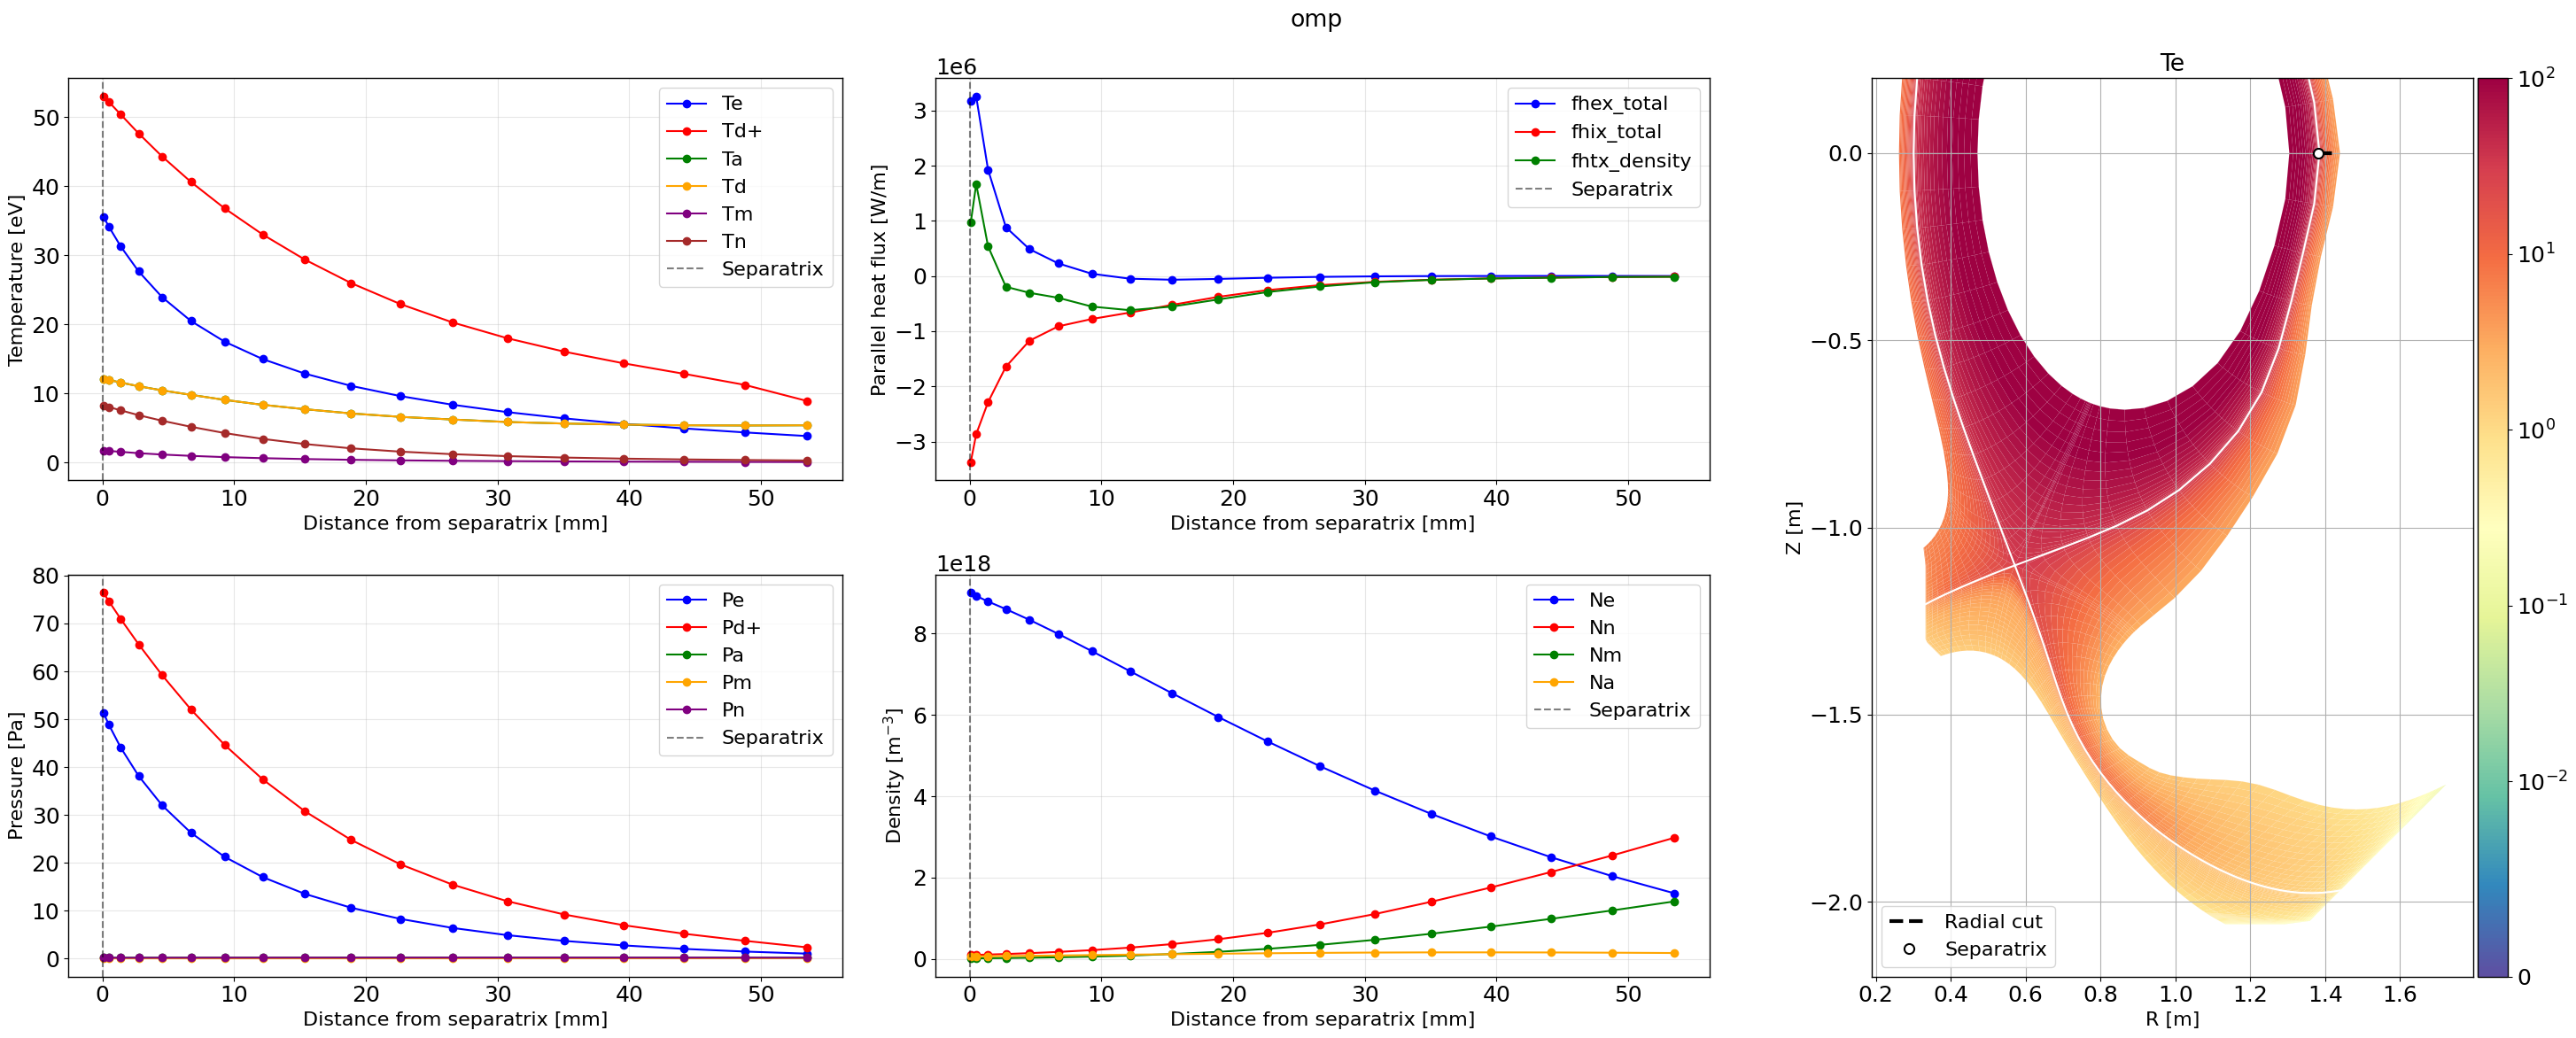

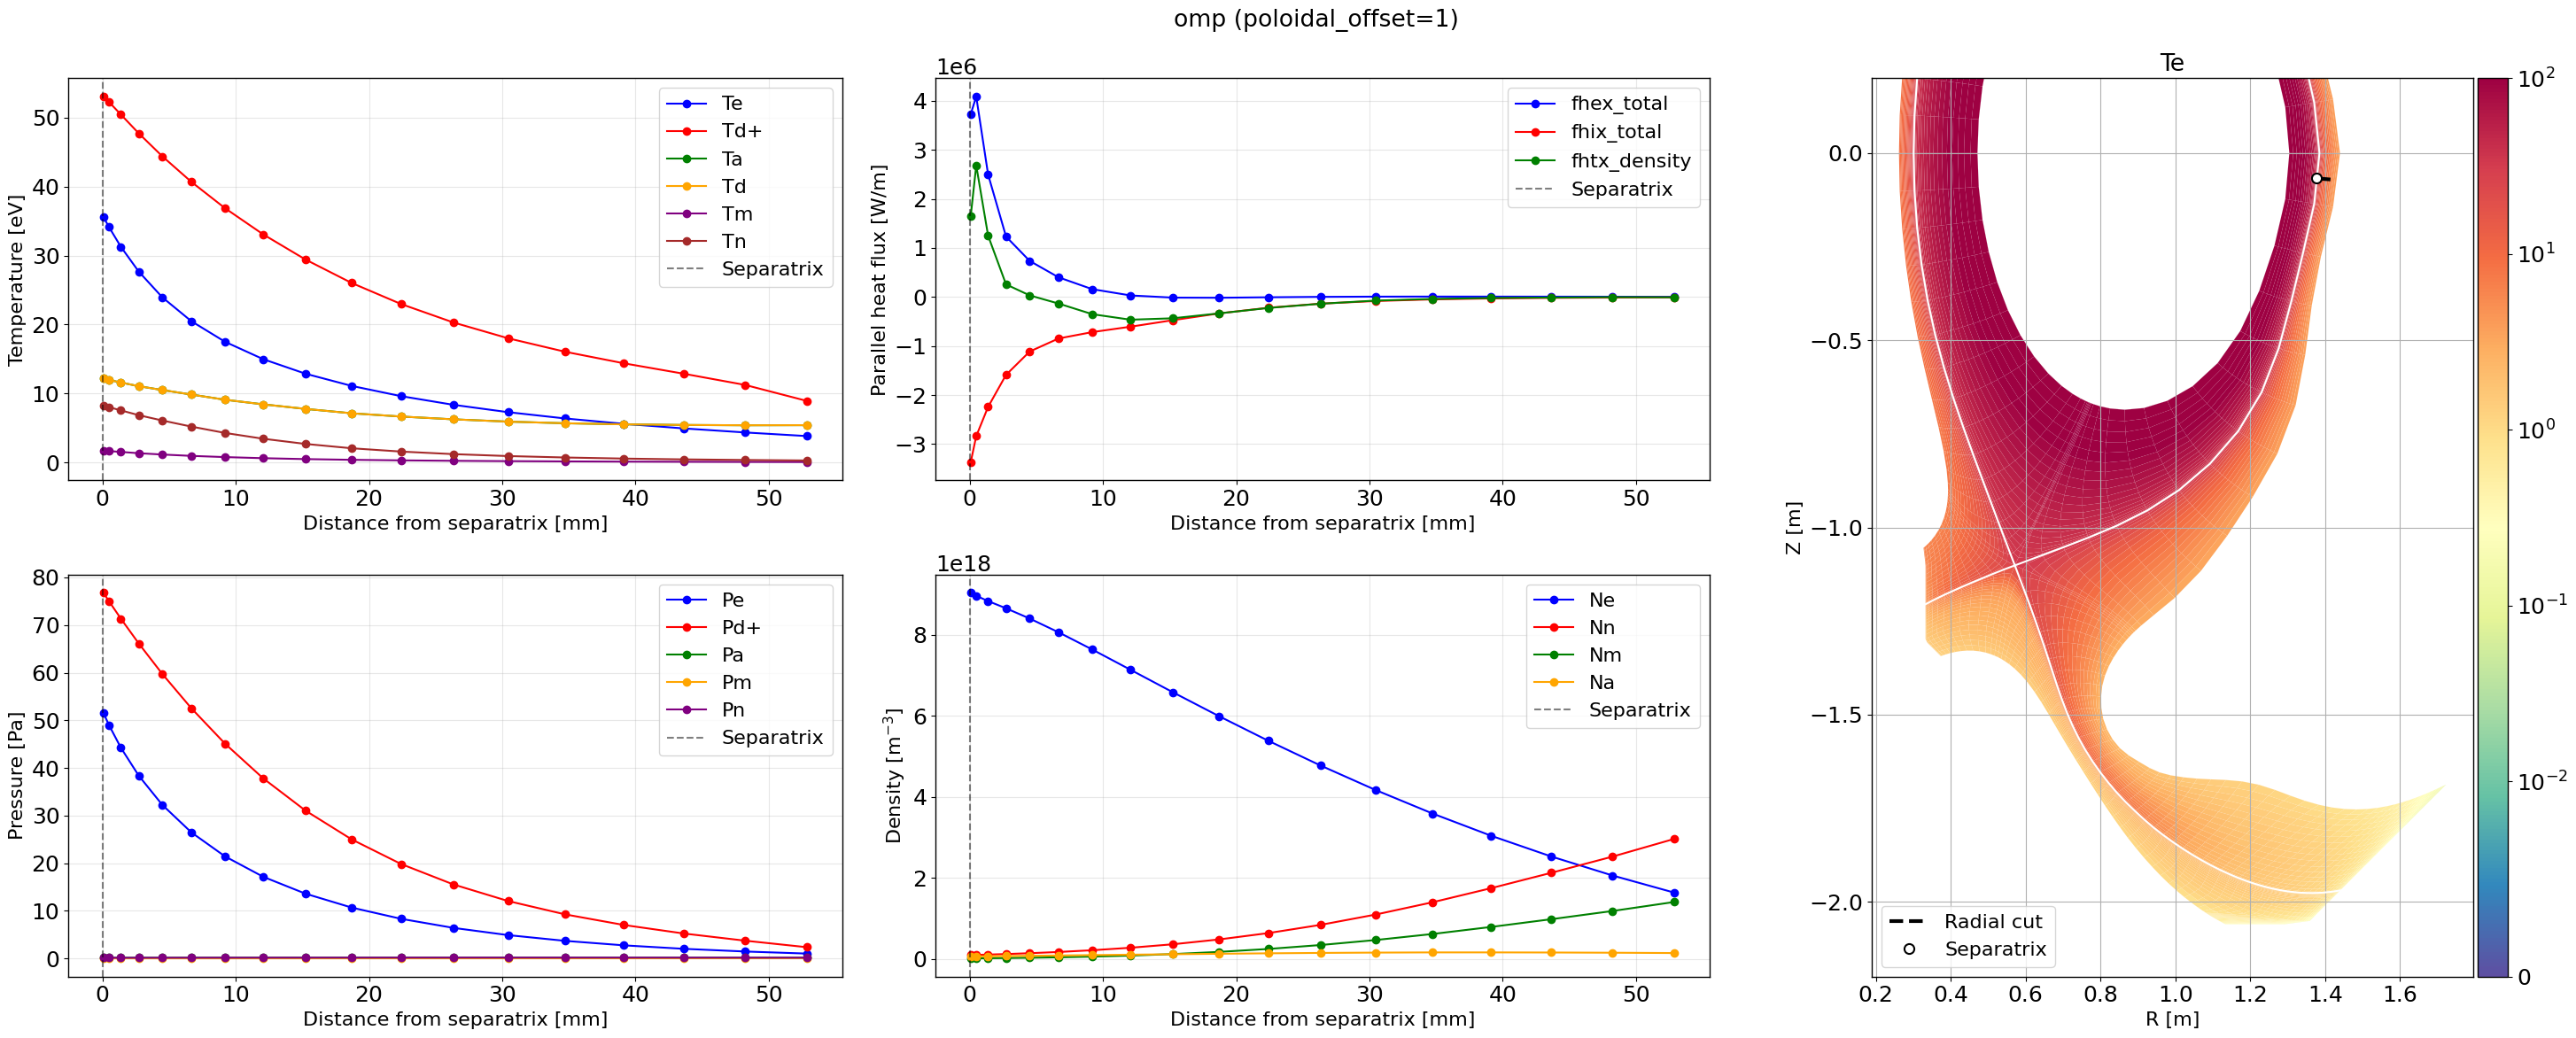

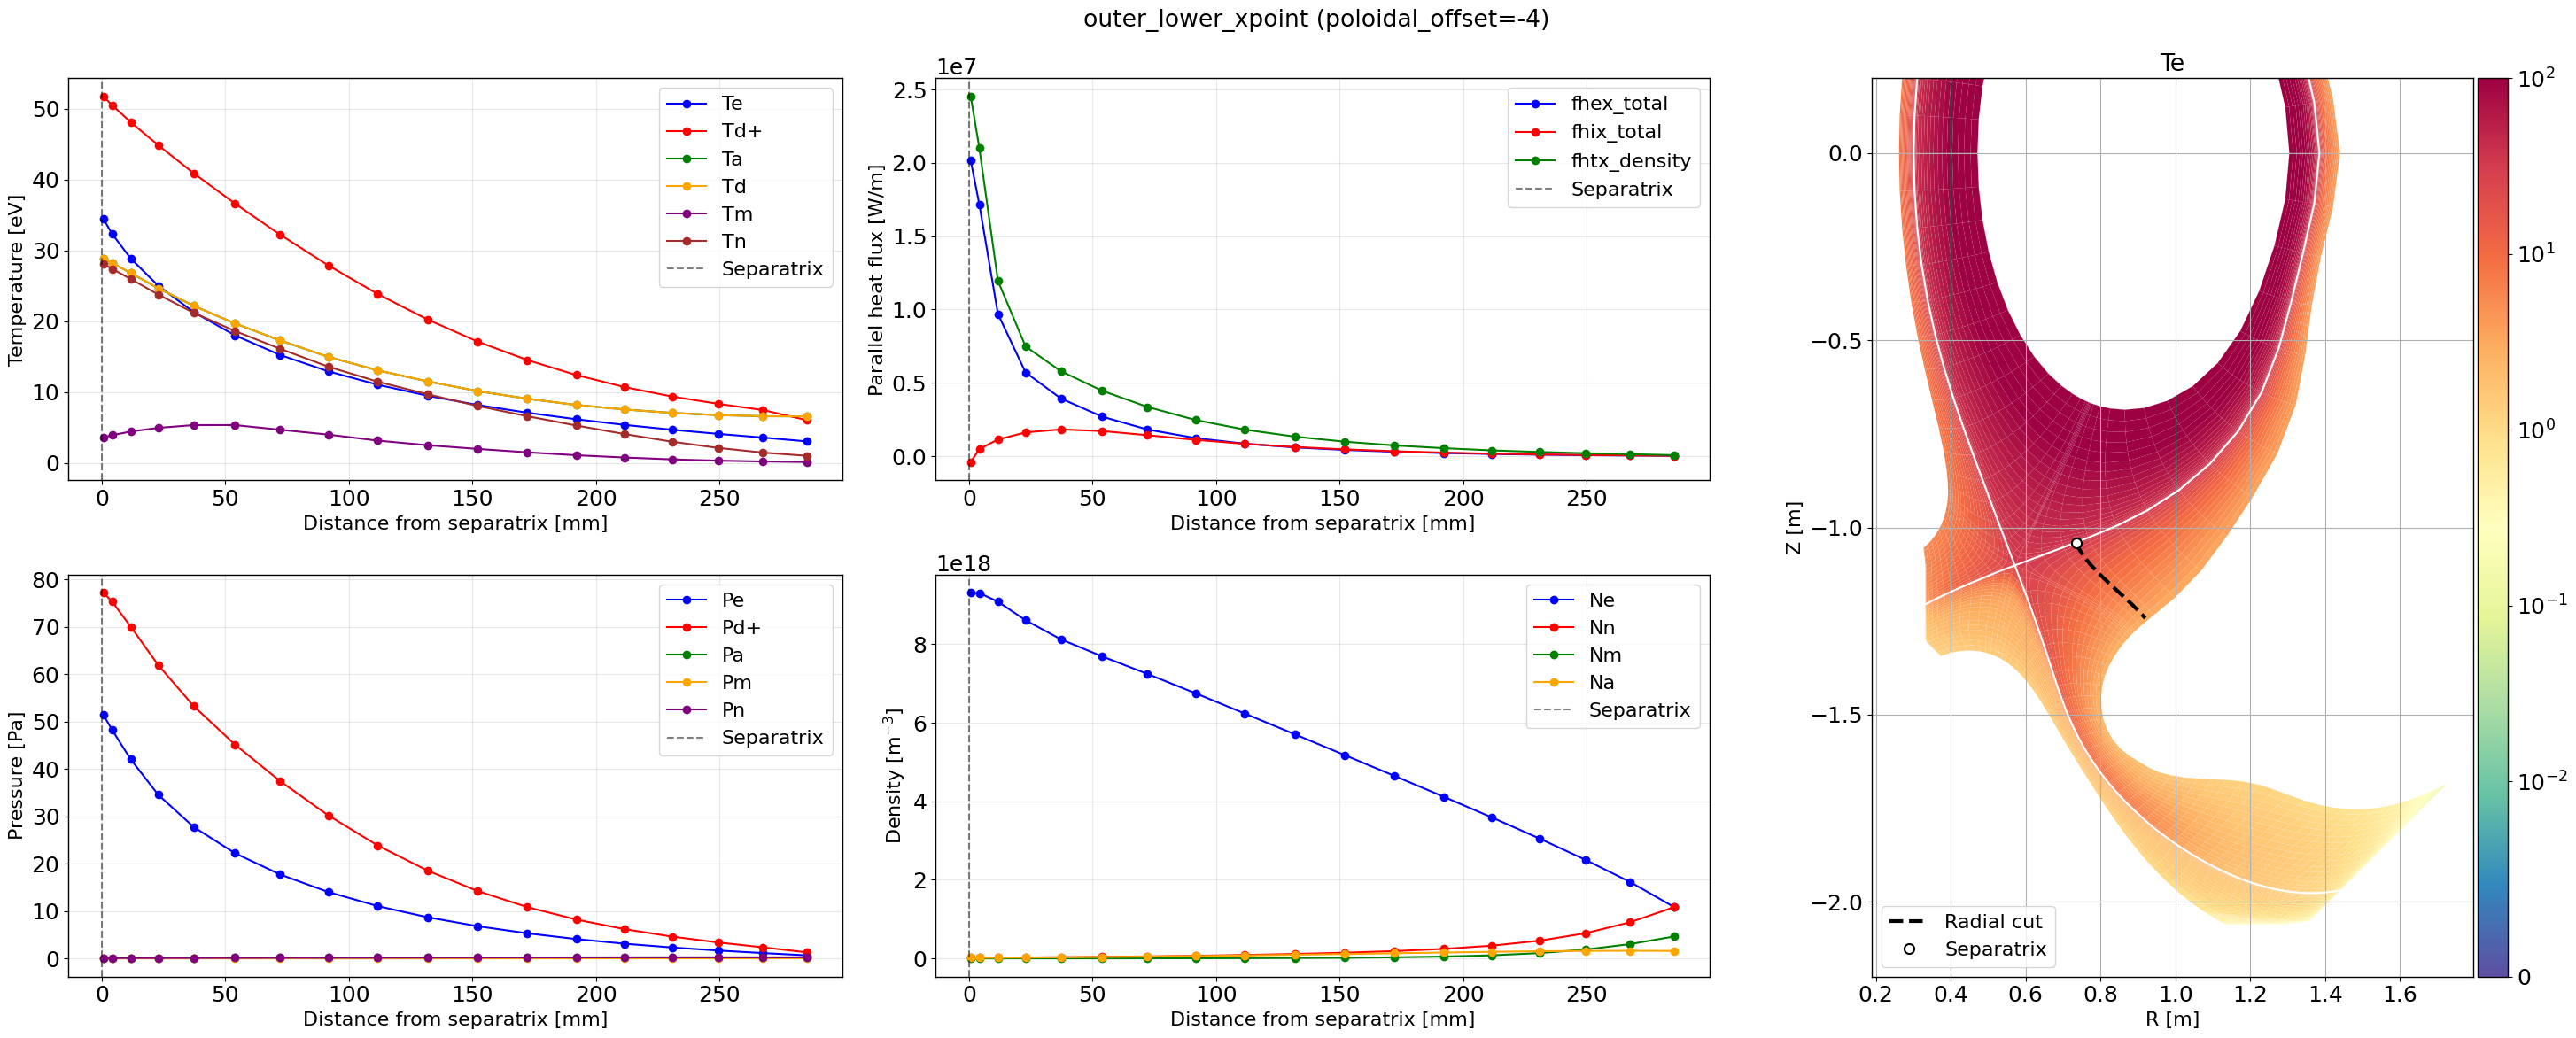

In [ ]:
# Using plot_radial_profiles with poloidal_offset to plot profiles below OMP
# Positive values move downward (toward lower target)

# OMP baseline
plot_radial_profiles(case, region='omp', poloidal_offset=0, zoom=False, param_2d='Te', grid_only=False, cfr_only=True)

# 1 grid point below OMP
plot_radial_profiles(case, region='omp', poloidal_offset=1, zoom=False, param_2d='Te', grid_only=False, cfr_only=True)

# 2 grid points below OMP
plot_radial_profiles(case, region='outer_lower_xpoint', poloidal_offset=-4, zoom=False, param_2d='Te', grid_only=False, cfr_only=True)


# Determine radial peak

# Calculate $\lambda_q$ at peak parallel power

Exponential fit:
  λq: 53.32 mm
  Amplitude: 4.33e+07 W/m²


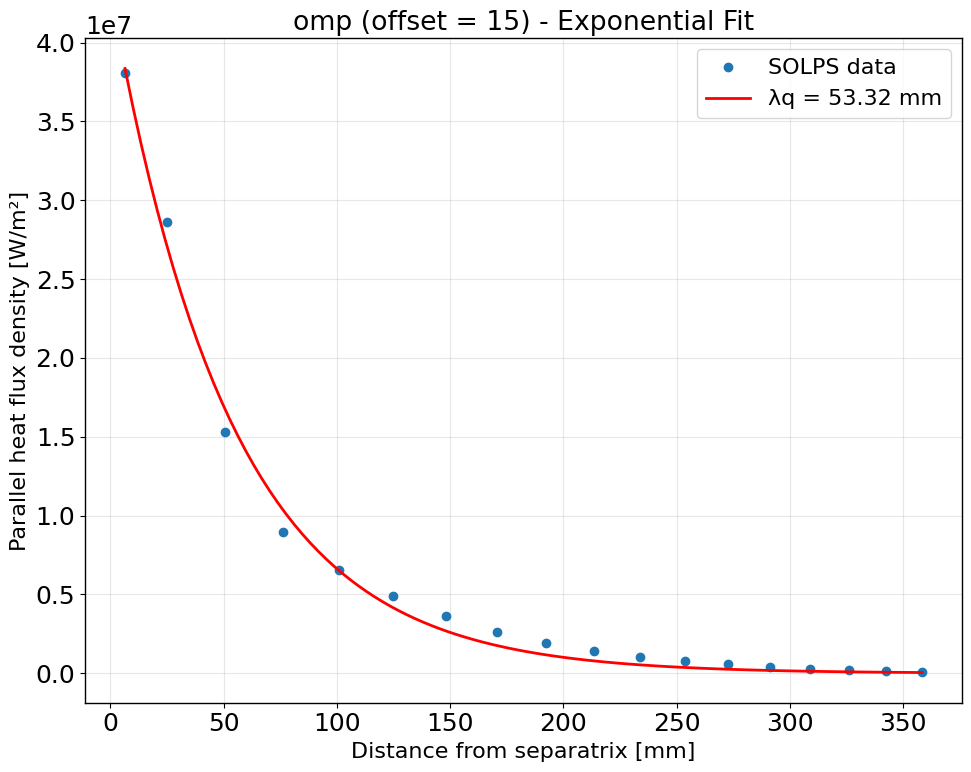

Exponential fit:
  λq: 182.51 mm
  Amplitude: 3.16e+05 W/m²


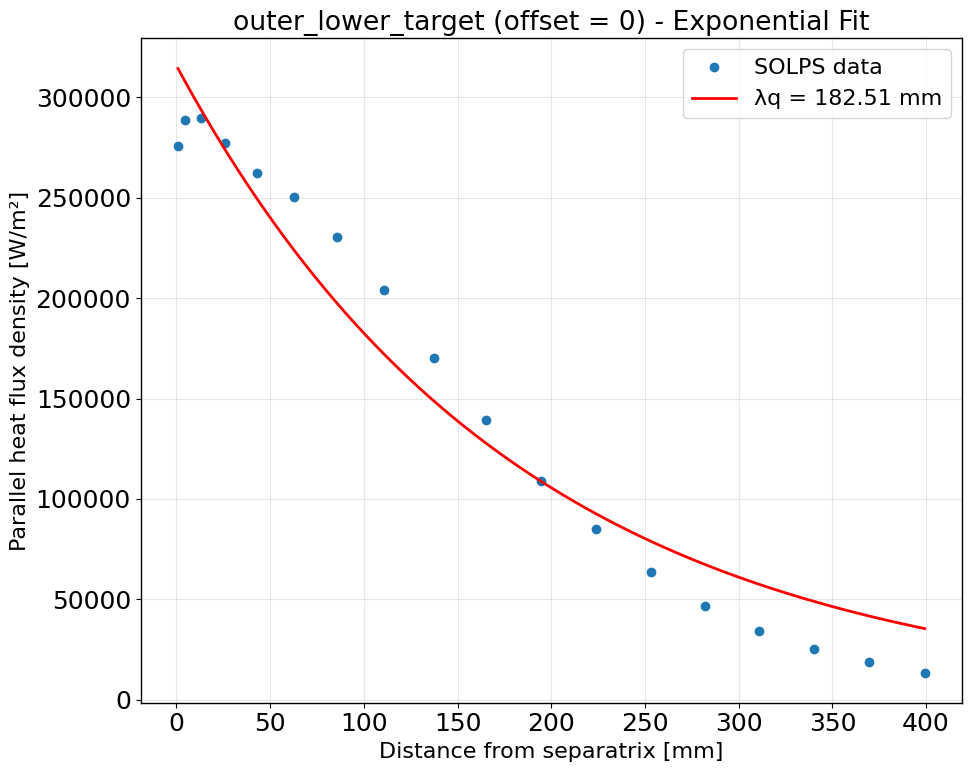

In [ ]:
from scipy.optimize import curve_fit
from scipy.special import erfc
import numpy as np
import matplotlib.pyplot as plt


def get_lambda_q(case, region="omp",poloidal_offset=0, method="exponential", plot=True, 
                 range=(0.0, None), go_from_peak=False):
    # Load data
    fline = case.get_1d_radial_data(
        ["Te", "ne", 'Nn', "Pe", 'fhex_total', 'fhix_total', 'fhey_total', 'fhtx', 'fhty'], 
        region=region,
        keep_geometry=True,
        poloidal_offset=poloidal_offset
    )
    
    ds = fline.copy()

    if range[0] is not None:
        sep_indx = np.searchsorted(ds['dist'].values, range[0], side='right')
        ds = ds.iloc[sep_indx:]

    if range[1] is not None:
        upper_indx = np.searchsorted(ds['dist'].values, range[1], side='right')
        ds = ds.iloc[:upper_indx]
    
    if go_from_peak and method == "exponential":
        q_parallel = ds['fhtx']/ds['apar']
        peak_idx = q_parallel.idxmax()
        pos_from_peak = ds.index.get_loc(peak_idx)
        ds = ds.iloc[pos_from_peak:]
    
    # Select heat flux field based on method
    if method == "eich":
        q_parallel = ds['fhtx'].values / ds['apar'].values  # Use fhtx for Eich
    else:
        q_parallel = ds['fhtx'].values / ds['apar'].values
    
    s_bar = ds['dist'].values  # radial distance from separatrix

    
    if method == "exponential":
        # Simple exponential decay fit
        def fit_func(r, a, lmq):
            return a * np.exp(-r/lmq)
        
        p0 = [q_parallel[0], 0.005]
        
        try:
            popt, pcov = curve_fit(fit_func, s_bar, q_parallel, p0=p0)
            a, lambda_q = popt
            
            print(f"Exponential fit:")
            print(f"  λq: {lambda_q*1000:.2f} mm")
            print(f"  Amplitude: {a:.2e} W/m²")
            
            result = {'lambda_q': lambda_q, 'amplitude': a}
            
            if plot:
                fig, ax = plt.subplots(figsize=(10, 8))
                ax.plot(s_bar * 1000, q_parallel, 'o', label='SOLPS data', markersize=6)
                
                r_fit = np.linspace(s_bar.min(), s_bar.max(), 100)
                q_fit = fit_func(r_fit, a, lambda_q)
                ax.plot(r_fit * 1000, q_fit, 'r-', linewidth=2, 
                        label=f'λq = {lambda_q*1000:.2f} mm')
                
                ax.set_xlabel(r"Distance from separatrix [mm]")
                ax.set_ylabel(r"Parallel heat flux density [W/m²]")
                ax.set_title(f"{region} (offset = {poloidal_offset}) - Exponential Fit")
                ax.legend()
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
        except RuntimeError as e:
            print(f"Exponential fit failed: {e}")
            return None
    
    elif method == "eich":
        # Eich profile fit
        def eich_fit(s_bar, q0, lambda_q, q_bg):
            """
            Eich profile at OMP (S=1, fx=1):
            q(s̄) = (q₀/2)·exp((s̄/(2λq))² - s̄/λq)·erfc(s̄/(2λq) - s̄) + q_BG
            """
            term1 = (s_bar / (2 * lambda_q))**2
            term2 = -s_bar / lambda_q
            exp_term = np.exp(term1 + term2)
            
            erfc_arg = s_bar / (2 * lambda_q) - s_bar
            erfc_term = erfc(erfc_arg)
            
            return (q0 / 2) * exp_term * erfc_term + q_bg
        
        # Initial guesses
        q_max = q_parallel.max()
        q_min = q_parallel.min()
        
        q0_guess = q_max * 2
        lambda_q_guess = 0.005
        q_bg_guess = max(0, q_min * 0.1)
        
        p0 = [q0_guess, lambda_q_guess, q_bg_guess]
        
        bounds = (
            [q_max * 0.1, 0.0001, 0],
            [q_max * 10, 0.05, q_max * 0.5]
        )
        
        print(f"Initial guesses: q0={q0_guess:.2e}, λq={lambda_q_guess*1000:.2f}mm, q_bg={q_bg_guess:.2e}")
        
        try:
            popt, pcov = curve_fit(eich_fit, s_bar, q_parallel, p0=p0, 
                                   bounds=bounds, max_nfev=10000)
            q0, lambda_q, q_bg = popt
            perr = np.sqrt(np.diag(pcov))
            
            print(f"\nEich fit parameters:")
            print(f"  q₀: {q0:.2e} ± {perr[0]:.2e} W/m²")
            print(f"  λq: {lambda_q*1000:.2f} ± {perr[1]*1000:.2f} mm")
            print(f"  q_BG: {q_bg:.2e} ± {perr[2]:.2e} W/m²")
            
            result = {
                'lambda_q': lambda_q, 
                'q0': q0, 
                'q_bg': q_bg,
                'errors': {'q0': perr[0], 'lambda_q': perr[1], 'q_bg': perr[2]}
            }
            
            if plot:
                fig, ax = plt.subplots(figsize=(12, 8))
                ax.plot(s_bar * 1000, q_parallel, 'o', label='SOLPS data', markersize=6)
                
                s_fit = np.linspace(s_bar.min(), s_bar.max(), 200)
                q_fit = eich_fit(s_fit, q0, lambda_q, q_bg)
                ax.plot(s_fit * 1000, q_fit, 'r-', linewidth=2, 
                        label=f'Eich fit: λq = {lambda_q*1000:.2f} mm')
                
                if s_bar.max() > lambda_q:
                    ax.axvline(lambda_q * 1000, color='green', linestyle='--', 
                               alpha=0.5, label=f'λq = {lambda_q*1000:.2f} mm')
                
                ax.set_xlabel(r"Distance from separatrix [mm]")
                ax.set_ylabel(r"Parallel electron heat flux [W/m²]")
                ax.set_title(f"{region} (offset = {poloidal_offset}) - Eich Fit")
                ax.legend()
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
        except (RuntimeError, ValueError) as e:
            print(f"Eich fit failed: {e}")
            return None
    
    elif method == "gaussian":
        # Gaussian fit for FWHM
        def gaussian(r, a, r0, sigma):
            return a * np.exp(-(r - r0)**2 / (2 * sigma**2))
        
        # Initial guesses
        peak_idx = np.argmax(q_parallel)
        a_guess = q_parallel[peak_idx]
        r0_guess = s_bar[peak_idx]
        sigma_guess = 0.007
        
        p0 = [a_guess, r0_guess, sigma_guess]
        
        try:
            popt, pcov = curve_fit(gaussian, s_bar, q_parallel, p0=p0)
            a, r0, sigma = popt
            
            fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma  # ≈ 2.355 * sigma
            
            print(f"Gaussian fit parameters:")
            print(f"  Peak amplitude (a): {a:.2e} W/m²")
            print(f"  Peak position (r0): {r0*1000:.2f} mm")
            print(f"  Sigma: {sigma*1000:.2f} mm")
            print(f"  FWHM: {fwhm*1000:.2f} mm")
            
            result = {'fwhm': fwhm, 'sigma': sigma, 'peak': a, 'r0': r0}
            
            if plot:
                fig, ax = plt.subplots(figsize=(10, 8))
                ax.plot(s_bar * 1000, q_parallel, 'o', label='SOLPS data', markersize=6)
                
                r_fit = np.linspace(s_bar.min(), s_bar.max(), 200)
                q_fit = gaussian(r_fit, a, r0, sigma)
                ax.plot(r_fit * 1000, q_fit, 'r-', linewidth=2, 
                        label=f'Gaussian fit: FWHM = {fwhm*1000:.2f} mm')
                
                ax.axvline(r0 * 1000, color='green', linestyle='--', 
                           alpha=0.5, label=f'Peak at {r0*1000:.2f} mm')
                
                fwhm_left = r0 - fwhm/2
                fwhm_right = r0 + fwhm/2
                ax.axvline(fwhm_left * 1000, color='orange', linestyle='--', alpha=0.5)
                ax.axvline(fwhm_right * 1000, color='orange', linestyle='--', alpha=0.5)
                
                ax.set_xlabel(r"Distance from separatrix [mm]")
                ax.set_ylabel(r"Parallel electron heat flux [W/m²]")
                ax.set_title(f"{region} (offset = {poloidal_offset}) - Gaussian FWHM")
                ax.legend()
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
        except RuntimeError as e:
            print(f"Gaussian fit failed: {e}")
            return None
    
    else:
        raise ValueError(f"Unknown method: {method}. Choose 'exponential', 'eich', or 'gaussian'")
    
    return result


# Example usage:
# Exponential fit
result = get_lambda_q(case, region='omp', poloidal_offset=15, method='exponential', range=(0.0, None))
lambda_q = result['lambda_q']

result = get_lambda_q(case, region='outer_lower_target', poloidal_offset=0, method='exponential', range=(0.0, None))


# # Eich fit
# result = get_lambda_q(case, region='omp', poloidal_offset=15, method='eich', range=(0.0, None))
# lambda_q = result['lambda_q']

# # Gaussian FWHM
# result = get_lambda_q(case, region='omp',poloidal_offset=15, method='gaussian', range=(0.0, None))
# fwhm = result['fwhm']

In [ ]:
def calculate_parallel_power_xpoint(case, sepadd=0, sepdist=None, region='outer_lower', 
                                   poloidal_offset=0, verbose=True, lambda_q_method=None, plot=False):
    """
    Calculate parallel power at the X-point by summing over SOL rings.
    
    Arguments:
        case: The case object
        sepadd: Number of SOL rings to sum over
        sepdist: Radial distance from separatrix to sum over
        region: Region to analyze ('outer_lower', etc.)
        lambda_q_method: If specified, use get_lambda_q to determine radial extent.
                        Options: 'exponential', 'eich', 'gaussian'
                        - 'exponential': simple exponential decay fit
                        - 'eich': Eich profile fit (returns lambda_q)
                        - 'gaussian': Gaussian fit (returns FWHM)
        verbose: If True, print results
        plot: Not used currently
    
    Returns:
        dict: Dictionary containing:
            - 'total_src': Total parallel heat flux at X-point [W/m²]
            - 'e_src': Electron heat flux at X-point [W/m²]
            - 'i_src': Ion heat flux at X-point [W/m²]
            - 'src_ratio': Electron/ion ratio
    """
    # Validate inputs
    if sum([lambda_q_method is not None, sepdist is not None, sepadd != 0]) > 1:
        raise ValueError("Specify only one of: sepadd, sepdist, or lambda_q_method")
    
    if lambda_q_method is not None and lambda_q_method not in ['exponential', 'eich', 'gaussian']:
        raise ValueError("lambda_q_method must be 'exponential', 'eich', or 'gaussian'")
    
    e_src = 0
    i_src = 0
    total_src = 0 

    # Determine radial extent using lambda_q_method
    if lambda_q_method is not None:
        fline_radial = case.get_1d_radial_data(
            params=["fhex_total", "fhix_total", "Bpol", "fhtx", "fhty"],
            region='omp',
            keep_geometry=True,
            poloidal_offset=poloidal_offset
        )
        
        result = get_lambda_q(case, region='omp', method=lambda_q_method,
                             poloidal_offset=poloidal_offset,
                             plot=False, range=(0.0, None),
                             go_from_peak=(lambda_q_method == 'exponential'))
        
        if result is None:
            raise ValueError(f"{lambda_q_method} fit failed - cannot determine radial extent")
        
        if lambda_q_method == 'exponential':
            sepdist = result['lambda_q']
            print(f"Using λq (exponential) = {sepdist*1000:.2f} mm")
        
        elif lambda_q_method == 'eich':
            sepdist = result['lambda_q']
            print(f"Using λq (Eich, S=1) = {sepdist*1000:.2f} mm")
        
        elif lambda_q_method == 'gaussian':
            sepdist = result['fwhm']
            print(f"Using FWHM = {sepdist*1000:.2f} mm")
        
        # Count SOL flux tubes within the determined distance
        valid_mask = (fline_radial['dist'] >= 0) & (fline_radial['dist'] <= sepdist)
        sepadd = np.sum(valid_mask) - 1  # -1 because sepadd=0 is the separatrix
        print(f"Summing over {sepadd + 1} flux tubes")

    elif sepdist is not None:
        fline_radial = case.get_1d_radial_data(
            params=["fhex_total", "fhix_total", "Bpol", "fhtx", "fhty"],
            region='omp',
            keep_geometry=False,
            poloidal_offset=poloidal_offset
        )
        # Count SOL flux tubes within sepdist
        valid_mask = (fline_radial['dist'] >= 0) & (fline_radial['dist'] <= sepdist)
        sepadd = np.sum(valid_mask) - 1  # -1 because sepadd=0 is the separatrix
        print(f"Found {sepadd + 1} flux tubes within {sepdist*1000:.2f} mm")

    # Sum parallel power at X-point across flux tubes
    for i in range(sepadd + 1):
        fline = case.get_1d_poloidal_data(
            params=["fhex_total", "fhix_total", "Bpol", "fhtx", "fhty", "gs_perp"],
            region=region,
            sepadd=i,
            target_first=False,
            guards=False,
            
        )
        xpoint_idx = np.argmin(fline['Bpol'])
        total_src += (fline['fhex_total'][xpoint_idx] + fline['fhix_total'][xpoint_idx])/fline['apar'][xpoint_idx]
        e_src += fline['fhex_total'][xpoint_idx]/fline['apar'][xpoint_idx]
        i_src += fline['fhix_total'][xpoint_idx]/fline['apar'][xpoint_idx]
    
    src_ratio = e_src/i_src if i_src != 0 else np.inf

    if verbose:
        print(f"Electron source: {e_src:.2e} W/m²")
        print(f"Ion source: {i_src:.2e} W/m²")
        print(f"Total source: {total_src:.2e} W/m²")
        print(f"e/i ratio: {src_ratio:.2f}")

    return {'total_src': total_src, 'e_src': e_src, 'i_src': i_src, 'src_ratio': src_ratio}


# Example usage:

# Using Eich fit
result = calculate_parallel_power_xpoint(case, region='outer_lower', lambda_q_method='exponential', poloidal_offset=15)
print(f"Results: {result}")

# # Using exponential fit
# result = calculate_parallel_power_xpoint(case, region='outer_lower', lambda_q_method='exponential')

# # Using Gaussian FWHM
# result = calculate_parallel_power_xpoint(case, region='outer_lower', lambda_q_method='gaussian')

# Manual distance specification (backwards compatible)
# result = calculate_parallel_power_xpoint(case, region='outer_lower', sepdist=0.005)

# # Manual ring count (backwards compatible)
# result = calculate_parallel_power_xpoint(case, region='outer_lower', sepadd=3)

Exponential fit:
  λq: 53.32 mm
  Amplitude: 4.33e+07 W/m²
Using λq (exponential) = 53.32 mm
Summing over 3 flux tubes
Electron source: 5.88e+07 W/m²
Ion source: 1.20e+07 W/m²
Total source: 7.08e+07 W/m²
e/i ratio: 4.92
Results: {'total_src': np.float64(70772112.76098657), 'e_src': np.float64(58815280.12293772), 'i_src': np.float64(11956832.638048857), 'src_ratio': np.float64(4.918968250486052)}


In [ ]:
sol_rings = 3
sol_ring_density ={}

fline = case.get_1d_radial_data(
    params=['Ne'],
    region='omp',
    keep_geometry=True,
    poloidal_offset=15
)

fline = fline[fline['dist'] >= 0]

# print(fline['Ne'])

print('Sol ring density:\n', fline['Ne'][0:3].values)

print('Average density:', np.mean(fline['Ne'][0:3]), 'm^-3')

# # Apply filter for dist >= 0 if requested by cfr_only
# if cfr_only:
#     radial_data_profile = radial_data[radial_data['dist'] >= 0].copy()
# else:
#     radial_data_profile = radial_data

Sol ring density:
 [1.05418397e+19 9.82621172e+18 9.03414910e+18]
Average density: 9.800733514476433e+18 m^-3


# Calculate heatflux width along the leg

Exponential fit:
  λq: 1.32 mm
  Amplitude: 1.49e+06 W/m²
0.001317106562328165
Exponential fit:
  λq: 1.88 mm
  Amplitude: 2.39e+06 W/m²
0.0018760512436007033
Exponential fit:
  λq: 2.54 mm
  Amplitude: 4.21e+06 W/m²
0.0025377164186091658
Exponential fit:
  λq: 3.13 mm
  Amplitude: 6.04e+06 W/m²
0.003125816692065608
Exponential fit:
  λq: 4.17 mm
  Amplitude: 7.62e+06 W/m²
0.004171032008615221
Exponential fit:
  λq: 5.78 mm
  Amplitude: 8.96e+06 W/m²
0.005783801198114777
Exponential fit:
  λq: 7.55 mm
  Amplitude: 1.03e+07 W/m²
0.007554735507509265
Exponential fit:
  λq: 8.95 mm
  Amplitude: 1.20e+07 W/m²
0.008948016556027364
Exponential fit:
  λq: 10.78 mm
  Amplitude: 1.35e+07 W/m²
0.010779663119988396
Exponential fit:
  λq: 12.70 mm
  Amplitude: 1.55e+07 W/m²
0.012695305354171158
Exponential fit:
  λq: 14.84 mm
  Amplitude: 1.80e+07 W/m²
0.014840981850761062
Exponential fit:
  λq: 17.95 mm
  Amplitude: 2.09e+07 W/m²
0.017947222315437324
Exponential fit:
  λq: 23.74 mm
  Amplitude: 2

/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_36810/345804606.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


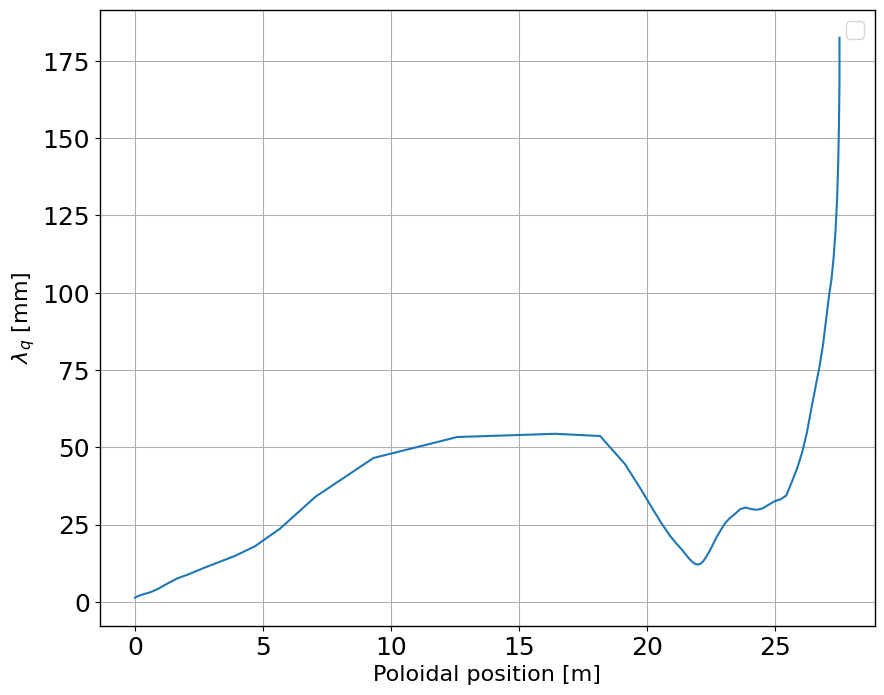

In [ ]:
# get length of outer lower


fline_pol = case.get_1d_poloidal_data(
    params = ['Te'],
    region = 'outer_lower',
    sepadd = 0,
    target_first = False,
    guards = False
)

len_pol = len(fline_pol['Spar'].values)

lmq_val = []

for i in range(len_pol):
    lmq = get_lambda_q(case, region='omp', poloidal_offset=i, method='exponential', range=(0.0, None), plot = False)['lambda_q']  
    print(lmq)  
    lmq_val.append(lmq)
lmq_val = np.array(lmq_val)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fline_pol['Spar'].values, lmq_val*1e3)
ax.set_xlabel('Poloidal position [m]')
ax.set_ylabel(r'$\lambda_q$ [mm]')
ax.legend()
plt.show()




